In [ ]:
import torch

time_series_times = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])  # 时间点
time_series = torch.tensor([10.0, 20.0, 30.0, 40.0, 50.0, 60.0])  # 对应的数据

t0_b = torch.tensor([1.5, 2.5])  # 开始时间点 (B,)
dt_b = torch.tensor([1.5, 3])  # 持续时间 (B,)

def extract_windows_with_times(time_series_times, time_series, t0_b, dt_b):
    """
    返回：extracted_values (B, max_len), extracted_times (B, max_len), mask (B, max_len)
    其中用 NaN 填充无效位置
    """
    start_idx = torch.searchsorted(time_series_times, t0_b, side='left') - 1          # (B,)
    end_idx = torch.searchsorted(time_series_times, t0_b + dt_b, side='right')     # (B,)

    lengths = end_idx - start_idx
    max_len = int(lengths.max().item())

    idx = start_idx.unsqueeze(1) + torch.arange(max_len, device=start_idx.device).unsqueeze(0)
    mask = idx < end_idx.unsqueeze(1)  # 有效位置掩码

    idx_clamped = torch.clamp(idx, 0, time_series.size(0) - 1)

    series_expanded = time_series.unsqueeze(0).expand(idx_clamped.size(0), -1)  # (B, N)
    extracted_values = series_expanded.gather(1, idx_clamped)                   # (B, max_len)
    extracted_values = extracted_values.masked_fill(~mask, float('nan'))

    times_expanded = time_series_times.unsqueeze(0).expand(idx_clamped.size(0), -1)
    extracted_times = times_expanded.gather(1, idx_clamped)
    extracted_times = extracted_times.masked_fill(~mask, float('nan'))

    return extracted_values, extracted_times, mask

# 示例调用
extracted, extracted_times, mask = extract_windows_with_times(time_series_times, time_series, t0_b, dt_b)
print(extracted)
print(extracted_times)


tensor([[20., 30., 40., nan],
        [30., 40., 50., 60.]])
tensor([[1., 2., 3., nan],
        [2., 3., 4., 5.]])


In [ ]:
import numpy as np
from scipy import interpolate

x = np.array([0.0, 1.0, 2.5, 4.0, 6.0])     # x 必须是单调递增
y = np.array([0.0, 2.0, 1.0, 3.0,  0.5])    # 对应 f(x) 的值 (≥ 0 表示累积单调)

f_interp = interpolate.interp1d(x, y, kind='linear',
                                bounds_error=False, fill_value=0.0)

x_dense = np.linspace(x[0], x[-1], 10001)
y_dense = f_interp(x_dense)

dx = x_dense[1] - x_dense[0]
F_dense = np.cumsum(y_dense) * dx  

F_dense = F_dense - F_dense[0]

F_inv = interpolate.interp1d(F_dense, x_dense, kind='linear',
                             bounds_error=False,
                             fill_value=(x_dense[0], x_dense[-1]))

def inverse_F(y0):
    return float(F_inv(y0))

# --- 4. 测试/展示 ---
if __name__ == "__main__":
    print("原始 (x, y):")
    for xi, yi in zip(x, y):
        print(xi, yi)

    print("\n积分后的总累计 F_max ≈", F_dense[-1])

    # 测试若干 F 取值, 看反函数输出
    for frac in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
        y0 = F_dense[-1] * frac
        x0 = inverse_F(y0)
        print(f"F_inv({y0:.3f}) ≈ x = {x0:.3f}")


原始 (x, y):
0.0 0.0
1.0 2.0
2.5 1.0
4.0 3.0
6.0 0.5

积分后的总累计 F_max ≈ 9.750149869999996
F_inv(0.000) ≈ x = 0.000
F_inv(0.975) ≈ x = 0.987
F_inv(2.438) ≈ x = 1.835
F_inv(4.875) ≈ x = 3.482
F_inv(7.313) ≈ x = 4.385
F_inv(8.775) ≈ x = 5.088
F_inv(9.750) ≈ x = 6.000


In [23]:
import torch

x = torch.tensor([0.0, 1.0, 2, 3, 4.0], dtype=torch.float32)
y = torch.tensor([0.0, 2.0, 1.0, 3.0, 0.5], dtype=torch.float32)

# 确保 x 单调递增
assert torch.all(x[1:] > x[:-1])
N = 10000
x_dense = torch.linspace(x[0], x[-1], N)
def linear_interp(x_src, y_src, x_query):
    # x_src: (n,), y_src: (n,), x_query: (m,)
    m = x_query.shape[0]
    yq = torch.zeros(m, dtype=torch.float32)
    idx = torch.searchsorted(x_src, x_query)  # 得到插入点
    # 对于 idx = 0 或 idx = len(x_src): 超出边界, 设为 0 (或边界值)
    for i in range(1, len(x_src)):
        mask = (idx == i)
        if torch.any(mask):
            x0, x1 = x_src[i-1], x_src[i]
            y0, y1 = y_src[i-1], y_src[i]
            xi = x_query[mask]
            yq[mask] = y0 + (y1 - y0) * (xi - x0) / (x1 - x0)
    return yq

y_dense = linear_interp(x, y, x_dense)

dx = x_dense[1] - x_dense[0]
F_dense = torch.cumsum(y_dense, dim=0) * dx  # F(x) 从 x[0] 到 x

def F_inv(y0_tensor, F_vals, x_vals):
    # y0_tensor: 任意标量或 tensor of queries
    # 返回同 shape 的 x estimates
    y0 = y0_tensor.clone().detach()
    # clamp to valid range
    y0 = torch.clip(y0, F_vals.min(), F_vals.max())
    idx = torch.searchsorted(F_vals, y0)
    # 防止 idx=0 or idx>=len
    idx = torch.clamp(idx, 1, len(F_vals)-1)
    x0 = x_vals[idx-1]; x1 = x_vals[idx]
    F0 = F_vals[idx-1]; F1 = F_vals[idx]
    return x0 + (x1 - x0) * (y0 - F0) / (F1 - F0)

# 5. 测试
if __name__ == "__main__":
    total = F_dense[-1].item()
    print("总累计 F_max ≈", total)
    for frac in [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]:
        y0 = total * frac
        x0 = F_inv(torch.tensor(y0), F_dense, x_dense)
        print(f"F_inv({y0:.3f}) ≈ x = {x0:.3f}")


总累计 F_max ≈ 6.250100135803223
F_inv(0.000) ≈ x = 0.000
F_inv(0.625) ≈ x = 0.790
F_inv(1.563) ≈ x = 1.304
F_inv(3.125) ≈ x = 2.435
F_inv(4.688) ≈ x = 3.064
F_inv(5.625) ≈ x = 3.465
F_inv(6.250) ≈ x = 4.000


In [38]:
import torchcde
def build_cif_inverse(x, y, num_dense=10000):
    assert x.ndim == 1 and y.ndim == 1 and x.shape == y.shape
    forward_interp = torchcde.LinearInterpolation(y.unsqueeze(0).unsqueeze(-1), t=x)
    x_dense = torch.linspace(x[0], x[-1], num_dense, device=x.device, dtype=x.dtype)
    y_dense = forward_interp.evaluate(x_dense).squeeze()  # (num_dense,)

    dx = x_dense[1] - x_dense[0]
    F_dense = torch.cumsum(y_dense, dim=0) * dx
    inverse_interp = torchcde.LinearInterpolation(x_dense.unsqueeze(0).unsqueeze(-1), t=F_dense)
    return {
        "forward_interp": forward_interp,
        "inverse_interp": inverse_interp
    }

res = build_cif_inverse(x, y, num_dense=N)
forward_interp = res["forward_interp"]
inverse_interp = res["inverse_interp"]

In [33]:
import torch
# 假设原始离散 (x, y)
x = torch.tensor([0.0, 1.0, 2.5, 4.0, 6.0], dtype=torch.float32, device='cuda')
y = torch.tensor([0.0, 2.0, 1.0, 3.0, 0.5], dtype=torch.float32, device='cuda')

# 构造 dense 网格 (单一)，然后 compute F_dense
N = 20000
x_dense = torch.linspace(x[0], x[-1], N, device='cuda')
# 使用广播 / vectorize 插值: 假设 linear_interp 已经是 vectorized (基于 tensor operations)
# 为简化，这里用 torch.searchsorted + gather + interpolation vectorized
idx = torch.searchsorted(x, x_dense)
idx = torch.clamp(idx, 1, x.shape[0]-1)
x0 = x[idx-1]; x1 = x[idx]
y0 = y[idx-1]; y1 = y[idx]
y_dense = y0 + (y1 - y0) * (x_dense - x0) / (x1 - x0)

dx = x_dense[1] - x_dense[0]
F_dense = torch.cumsum(y_dense, dim=0) * dx  # shape (N,)

# 假设我们有 batch of queries: 多个不同的累计值 y0_batch
y0_batch = torch.linspace(0.0, float(F_dense[-1]), steps=1000, device='cuda')  # (B,)
# 用 vectorized binary search + linear interpolation 得到 x_batch = F_inv(y0_batch)
idx_q = torch.searchsorted(F_dense, y0_batch)
idx_q = torch.clamp(idx_q, 1, F_dense.shape[0]-1)
Fx0 = F_dense[idx_q-1]; Fx1 = F_dense[idx_q]
X0 = x_dense[idx_q-1]; X1 = x_dense[idx_q]
x_batch = X0 + (X1 - X0) * (y0_batch - Fx0) / (Fx1 - Fx0)

# 现在 x_batch 是 batch of outputs，相当于并行地对多个 y0 同时计算 F_inv
print(x_batch.shape)  # torch.Size([1000])


torch.Size([1000])


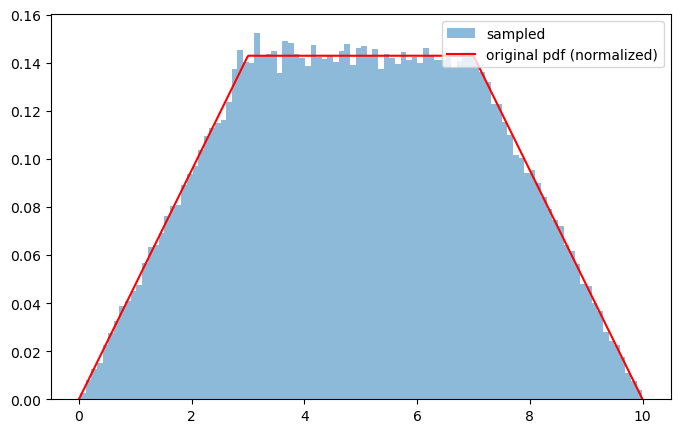

In [ ]:
import numpy as np
from lintsampler import LintSampler
import matplotlib.pyplot as plt

# 定义你的 PDF。以下以一个示例 piecewise‑linear / arbitrary PDF 为例 — 你也可以
# 用 piecewise‑linear／分段、或插值／手动给的 density 函数。

def my_pdf(x):
    # 例如：一个分段 / piecewise／任意形状的 PDF — 这里以简单例子为 demo
    # x 的取值假设在 [0, 10]
    # 在 0–3 区间，p(x) ~ linearly increase from 0 to 1
    # 在 3–7 区间，p(x) ~ constant = 1
    # 在 7–10 区间，p(x) ~ linearly decrease from 1 to 0
    p = np.zeros_like(x, dtype=float)
    # segment 1
    mask = (x >= 0) & (x < 3)
    p[mask] = (x[mask] - 0) / (3 - 0) * 1.0  # 从 0 到 1 线性
    # segment 2
    mask = (x >= 3) & (x < 7)
    p[mask] = 1.0
    # segment 3
    mask = (x >= 7) & (x <= 10)
    p[mask] = (10 - x[mask]) / (10 - 7) * 1.0  # 从 1 线性下降到 0
    return p

# 构造一个 grid（定义 domain）
grid = np.linspace(0.0, 10.0, 200)  # 例如 200 个点，你也可以根据需要调整网格分辨率

# 使用 LintSampler 来采样
sampler = LintSampler(grid, pdf=my_pdf)
samples = sampler.sample(N=100000)  # 比如采样 100000 个点

# 可视化：绘制直方图 + 对比原 PDF (归一化后)
plt.figure(figsize=(8,5))
# 绘制样本 histogram (density=True 归一化为 pdf 形式)
plt.hist(samples, bins=100, density=True, alpha=0.5, label="sampled")
# 绘制 “真实” pdf curve
xs = np.linspace(0, 10, 500)
plt.plot(xs, my_pdf(xs)/np.trapz(my_pdf(xs), xs), 'r-', label="original pdf (normalized)")
plt.legend()
plt.show()


In [1]:
import torch
f_intensity = torch.load("f_intensity.pt") 
h_intensity = torch.load("h_intensity.pt")
ratio = torch.load("ratio.pt")
print(f"f_intensity: {f_intensity.mean().item():.4f}, h_intensity: {h_intensity.mean().item():.4f}, ratio: {ratio.mean().item():.4f}")

f_intensity: 0.5409, h_intensity: 26.8099, ratio: 0.0683


In [5]:
f_intensity.max().item(), h_intensity.max().item(), ratio.max().item()

(26.181413650512695, 6106.07275390625, 6.99670934677124)

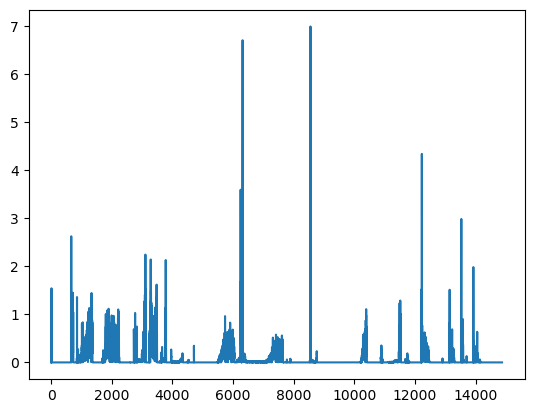

In [10]:
import numpy as np
import matplotlib.pyplot as plt
plt.plot(ratio.reshape(-1).detach().cpu().numpy())

In [1]:
from fast_hadamard_transform import hadamard_transform

In [3]:
import torch

w = torch.nn.Parameter(torch.ones(3))
w._no_weight_decay = True  # 打标记

opt = torch.optim.AdamW([w], lr=0.1, weight_decay=1.0)  # 没分组
w.grad = torch.ones_like(w) * 0.0  # 让更新主要来自 weight_decay
opt.step()

print(w)  # 你会看到 w 变小了 -> weight_decay 生效了
# 标记
p.no_weight_decay = True

# 构建 optimizer 时读取标记并分组
decay, no_decay = [], []
for n, p in model.named_parameters():
    if getattr(p, "no_weight_decay", False) or getattr(p, "_no_weight_decay", False):
        no_decay.append(p)
    else:
        decay.append(p)

opt = torch.optim.AdamW(
    [{"params": decay, "weight_decay": wd},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=lr
)



Parameter containing:
tensor([0.9000, 0.9000, 0.9000], requires_grad=True)


NameError: name 'p' is not defined

In [4]:
import torch

w1 = torch.nn.Parameter(torch.ones(3))
w2 = torch.nn.Parameter(torch.ones(3))

w2.no_weight_decay = True  # 只让 w2 不 decay

wd = 1.0
opt = torch.optim.AdamW(
    [
        {"params": [w1], "weight_decay": wd},
        {"params": [w2], "weight_decay": 0.0},  # ✅ 关键：分组里设置0
    ],
    lr=0.1,
)

w1.grad = torch.zeros_like(w1)
w2.grad = torch.zeros_like(w2)

b1 = w1.detach().clone()
b2 = w2.detach().clone()

opt.step()

print("w1 before/after/delta:", b1, w1.detach(), w1.detach() - b1)
print("w2 before/after/delta:", b2, w2.detach(), w2.detach() - b2)


w1 before/after/delta: tensor([1., 1., 1.]) tensor([0.9000, 0.9000, 0.9000]) tensor([-0.1000, -0.1000, -0.1000])
w2 before/after/delta: tensor([1., 1., 1.]) tensor([1., 1., 1.]) tensor([0., 0., 0.])
